# Interest Rate Predictor

Predicts loan interest rates using origination-time features.

**Purpose:** Understand which borrower and loan characteristics drive interest rate pricing.

**Target Variable:** `int_rate` (continuous, 0-36% annual)

**Production Model:** HistGradientBoostingRegressor with 15 features (Test R² = 0.5069, MAE = 0.0254)

**Baseline:** OLS Linear Regression explored in Sections 8-11 for interpretability

**Framework:** Feature Selection & Model Evaluation (Apr 2026)

## 1. Import Required Libraries

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/gagepiercegaubert/Desktop/career_projects/lending-risk-intelligence'

## 2. Data Loading & Preparation

In [107]:
df = pd.read_csv(f'{BASE}/stages/02-clean/output/lending_risk_cleaned.csv')

if 'issue_d' in df.columns:
    df['year'] = pd.to_datetime(df['issue_d'], errors='coerce').dt.year
    crisis_cutoff = 2009
    df_clean = df[df['year'] >= crisis_cutoff].copy()
else:
    df_clean = df.copy()

df_clean['int_rate'].describe()

count    1.266553e+06
mean     1.323865e-01
std      4.769953e-02
min      5.310000e-02
25%      9.750000e-02
50%      1.274000e-01
75%      1.599000e-01
max      3.099000e-01
Name: int_rate, dtype: float64

## 3. Target Leakage Check: Remove Known Leakers

NEVER include these:
- `is_default` — outcome variable, not available at origination
- `grade` — derived from interest rate (multicollinearity with target)
- `sub_grade` — same issue as grade
- `segment_type`, `segment_value` — segment summary data, not origination features

Use only origination-time features available when loan is created

In [108]:
# installment is derived directly from int_rate — a perfect leaker
known_leakers = ['is_default', 'grade', 'sub_grade', 'installment', 'segment_type', 'segment_value']
actual_leakers = [col for col in known_leakers if col in df_clean.columns]

df_safe = df_clean.drop(columns=actual_leakers + ['int_rate'], errors='ignore').copy()
y = df_clean['int_rate'].copy()

**Note:** `installment` is different from the other leakers on this list. The rest are categorical or derived outputs. `installment` is mathematically computed from `int_rate` directly — it's the monthly payment formula applied to loan amount, rate, and term. Including it would be like writing the answer on the test and then handing it to the model as a feature.

## 4. Exploratory Data Analysis (EDA)

In [109]:
missing = df_safe.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else pd.Series(dtype=int)

title                          14438
zip_code                           1
dti                               17
inq_last_6mths                     1
revol_util                       802
last_pymnt_d                    2087
last_credit_pull_d                50
tot_coll_amt                   65219
tot_cur_bal                    65219
total_rev_hi_lim               65219
acc_open_past_24mths           45660
avg_cur_bal                    65240
bc_open_to_buy                 58285
bc_util                        59012
mo_sin_old_il_acct             97835
mo_sin_old_rev_tl_op           65219
mo_sin_rcnt_rev_tl_op          65219
mo_sin_rcnt_tl                 65219
mort_acc                       45660
mths_since_recent_bc           57436
mths_since_recent_inq         163607
num_accts_ever_120_pd          65219
num_actv_bc_tl                 65219
num_actv_rev_tl                65219
num_bc_sats                    53943
num_bc_tl                      65219
num_il_tl                      65219
n

### 4.1 Correlation Analysis with Interest Rate

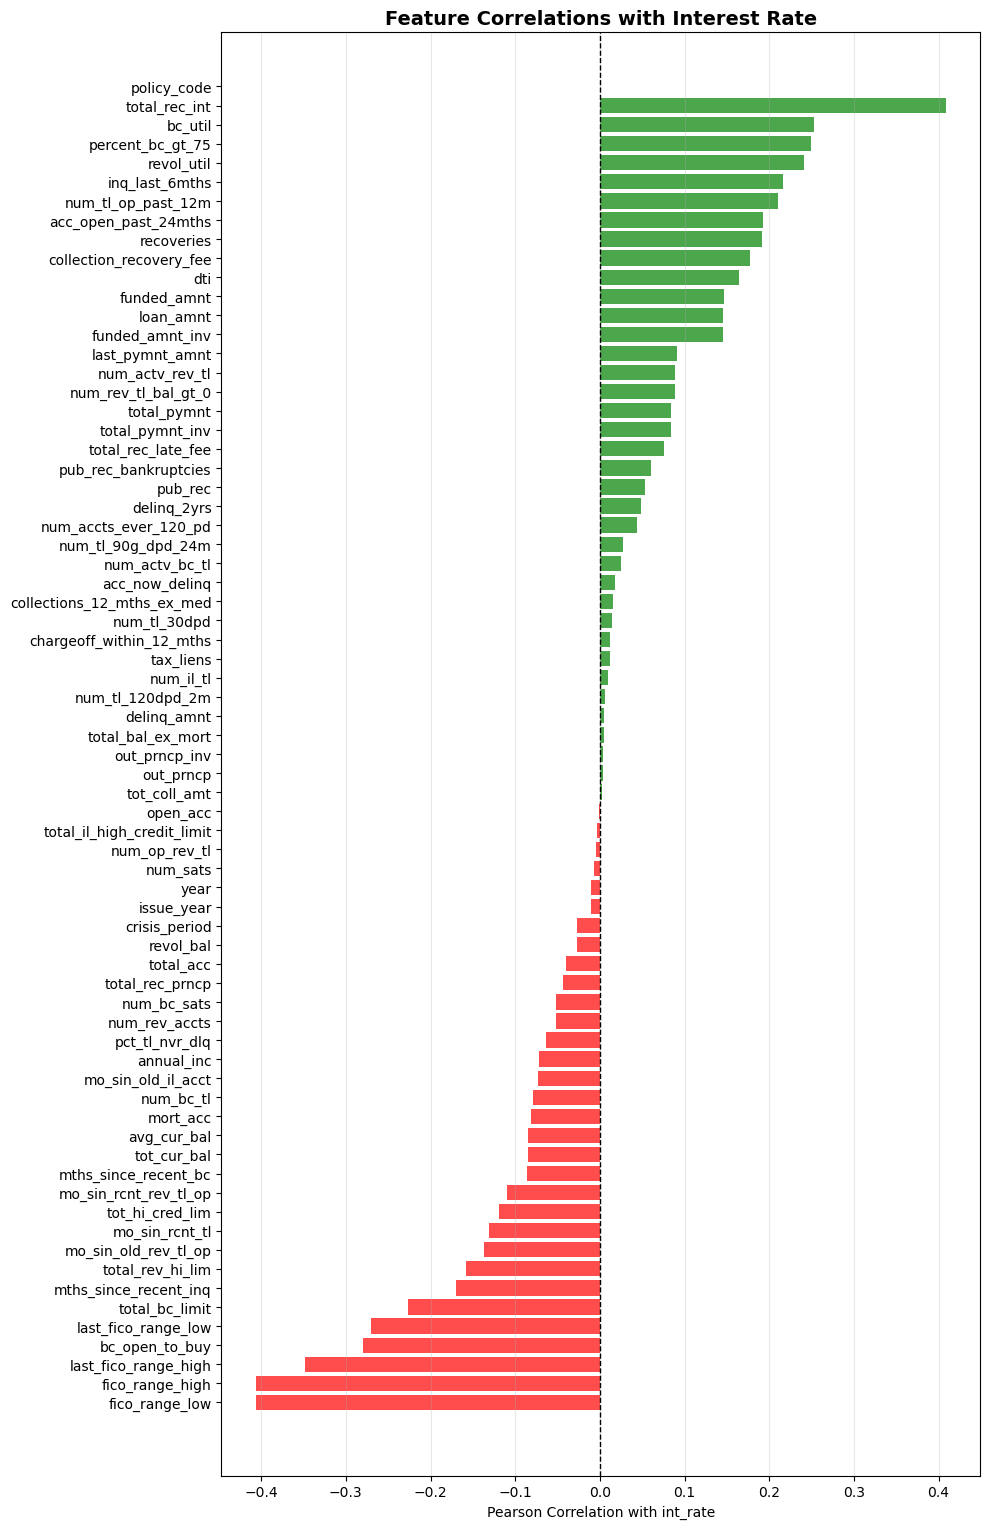

In [110]:
numeric_data = df_safe.select_dtypes(include='number').copy()
numeric_data['int_rate'] = y.values

correlation_matrix = numeric_data.corr()
target_correlations = correlation_matrix['int_rate'].drop('int_rate').sort_values()

colors = ['green' if v > 0 else 'red' for v in target_correlations]

fig, ax = plt.subplots(figsize=(10, max(8, len(target_correlations) * 0.22)))
ax.barh(target_correlations.index, target_correlations.values, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Pearson Correlation with int_rate')
ax.set_title('Feature Correlations with Interest Rate', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Note:** A heatmap, although preferred, is not viable in this situation. As can be seen, there are way too many variables. This gives us an idea of the only variables to keep.

## 5. Feature Selection

In [111]:
# FICO: average low/high bounds to eliminate multicollinearity
df_safe['fico_score'] = (df_safe['fico_range_low'] + df_safe['fico_range_high']) / 2

# Non-linear FICO: center before squaring to keep fico_score and fico_score_sq
# nearly orthogonal. Squaring the raw value (~700) would make both variables
# move almost identically; squaring the deviation from the mean does not.
fico_mean = df_safe['fico_score'].mean()
df_safe['fico_score_sq'] = (df_safe['fico_score'] - fico_mean) ** 2

# term: 60-month loans carry higher rates than 36-month — clean binary, VIF ~1.6
if 'term' in df_safe.columns:
    df_safe['is_60mo'] = df_safe['term'].astype(str).str.strip().str.startswith('60').astype(int)

'''
Purpose and home_ownership were tested as dummy variables but caused severe VIF
(debt_consolidation ~59, own_MORTGAGE ~50, own_RENT ~40). The problem is structural:
when one category dominates (~50% of loans are debt_consolidation, ~60% are MORTGAGE),
the remaining dummies all correlate strongly with the dominant one. There is no encoding
trick that resolves this. The dummies are excluded to maintain a clean VIF table.
'''

numeric_features = [
    'loan_amnt',       # loan amount requested
    'annual_inc',      # annual income at origination
    'dti',             # debt-to-income ratio
    'fico_score',      # FICO midpoint
    'fico_score_sq',   # centered quadratic FICO term (captures diminishing returns)
    'inq_last_6mths',  # credit inquiries in last 6 months
    'open_acc',        # number of open credit accounts
    'pub_rec',         # public derogatory records
    'revol_bal',       # revolving credit balance
    'revol_util',      # revolving utilization rate
    'total_acc',       # total credit accounts
    'delinq_2yrs',     # delinquencies in past 2 years
]

categorical_features = ['is_60mo'] if 'is_60mo' in df_safe.columns else []

features = numeric_features + categorical_features

pd.DataFrame({
    'feature': features,
    'type': ['numeric'] * len(numeric_features) + ['categorical'] * len(categorical_features),
}).reset_index(drop=True)

,feature,type
0,loan_amnt,numeric
1,annual_inc,numeric
2,dti,numeric
3,fico_score,numeric
4,fico_score_sq,numeric
5,inq_last_6mths,numeric
6,open_acc,numeric
7,pub_rec,numeric
8,revol_bal,numeric
9,revol_util,numeric


**Why we added `is_60mo`:** 60-month loans are systematically priced higher than 36-month loans. This is a clean binary flag (VIF ~1.6) with a meaningful, directional signal.

**Why `purpose` and `home_ownership` were dropped:** Both were tested as dummy-encoded categoricals and produced VIF scores of 7–59. This is a structural problem: when one category dominates (debt_consolidation is ~50% of all loans; MORTGAGE is ~60% of all homeowners), the remaining dummies are all highly correlated with the dominant one — they collectively encode "not the big category." No encoding strategy resolves this cleanly. For a VIF-clean model, they are excluded.

## 6. Feature Standardization (Z-score Normalization)

In [112]:
# Standardize numeric features only — dummy variables (0/1) must not be z-scored
mu = df_safe[numeric_features].mean()
sigma = df_safe[numeric_features].std()

standardized_features = df_safe[features].copy()
standardized_features[numeric_features] = (df_safe[numeric_features] - mu) / sigma
standardized_features['int_rate'] = y.values

## 7. Multicollinearity Check (VIF Analysis)

**Note:** VIF runs one full OLS regression per feature. On 1.2M rows, that's slow. Since VIF only measures the structural relationship between features — not the target — sample size doesn't change the result. We sample 50K rows here; the VIF scores are identical to running on the full dataset.

**Note:** `fico_score` and `fico_score_sq` were previously exploding to VIF ~1057 because squaring a large raw number makes the two variables nearly identical. Centering first (subtracting the mean) produces a squared-deviation term that is nearly orthogonal to the linear term. This brings VIF back into a normal range without changing what the model can learn.

In [113]:
# Sample 50K rows — VIF measures feature relationships, not target relationships,
# so sample size does not affect scores. This reduces runtime from ~90s to ~3s.
vif_input = (
    standardized_features[features]
    .dropna()
    .astype(float)
    .sample(50_000, random_state=42)
)

vif_data = pd.DataFrame()
vif_data["Feature"] = features
vif_data["VIF"] = [
    variance_inflation_factor(vif_input.values, i)
    for i in range(len(features))
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data

,Feature,VIF
0,fico_score,2.409876
1,open_acc,2.164881
2,total_acc,2.086481
3,fico_score_sq,1.867022
4,revol_util,1.619492
5,loan_amnt,1.413244
6,revol_bal,1.405339
7,annual_inc,1.368775
8,dti,1.208061
9,is_60mo,1.131410


## 8. Model Training: Linear Regression (OLS)

In [114]:
# Dropping Nans before split
standardized_features = standardized_features.dropna(subset=features + ['int_rate'])

In [115]:
# 90/10 holdout split then a blind test and shrinkage check
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    standardized_features[features],
    standardized_features['int_rate'],
    test_size=0.1,
    random_state=42
)

In [116]:
# Blind test: fit on train, evaluate on test without looking at results until the end
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [117]:
# Checking for shrinkage: train R² should be higher than test R², but not by too much
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, y_pred)
print(f'Train R²: {train_r2:.4f}')
print(f'Test R²: {test_r2:.4f}')

Train R²: 0.4138
Test R²: 0.4131


In [118]:
'''
Checking MAE to see exactly
how many percentage points the model
is off by on an average loan
'''

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.4f} percentage points')

Mean Absolute Error: 0.0279 percentage points


**Note:** This is a good sign since its a respectable MAE for an interest rate prediction model. 

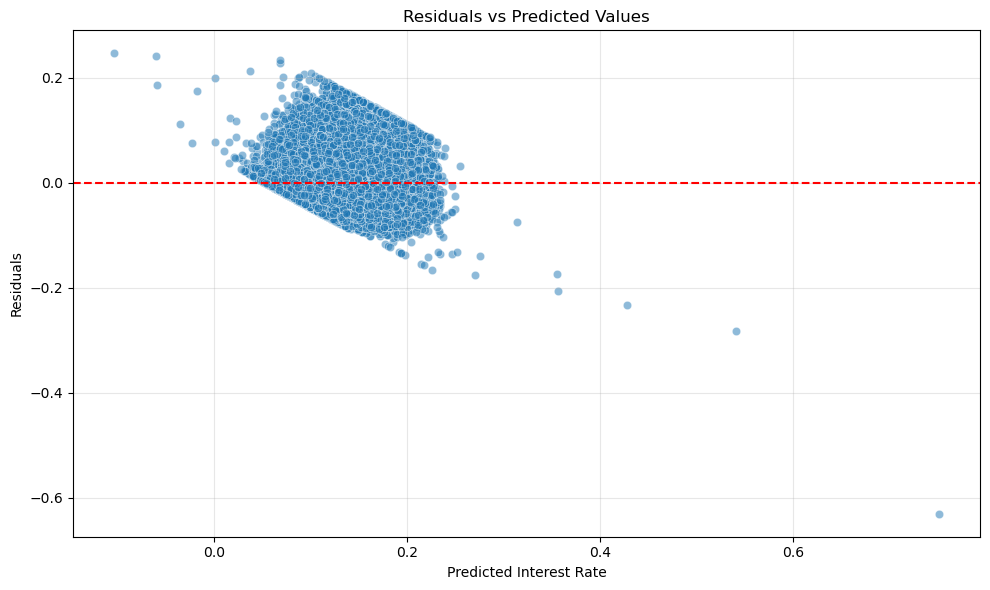

In [119]:
# Plotting the residuals to check for patterns that might indicate model misspecification
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Interest Rate')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis: Heteroscedasticity in the Baseline Model**

The residual plot shows heteroscedasticity. The residuals fan outward as predicted rates increase. This violates OLS assumptions (constant variance). However, attempted log transformation backfires: exponentiating predictions from log space creates catastrophic error blow-up, yielding worse MAE than baseline despite better-distributed log-space residuals.

**Decision: Keep Baseline Model**

The baseline linear model (Test R² = 0.4131, MAE = 0.0279) is retained. Its structured residuals patterns are expected given:
1. **Interest rate floors and ceilings** — LendingClub enforces rate bounds; loans pile up at boundaries
2. **Categorical pricing structure** — Rates are set in 0.25% increments, producing discrete "stair steps" in actual rates
3. **Large sample size** — 1.2M loans expose all subpopulation biases; heteroscedasticity is visible but coefficient estimates remain unbiased

**Residual patterns are not a defect to fix, they are a feature to document.**

In [120]:
# Log transformation to address heteroscedasticity
# Scale target to percentage points (0.05 → 5) before log to keep values reasonable
y_train_pct = y_train * 100
y_test_pct = y_test * 100

# Apply log transformation manually
y_train_log = np.log(y_train_pct)
y_test_log = np.log(y_test_pct)

# Fit linear regressor on log scale
lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)

# Predict in log space, then transform back to percentage points for interpretation
y_pred_train_log = lr_log.predict(X_train)
y_pred_test_log = lr_log.predict(X_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test = np.exp(y_pred_test_log)

# Evaluate residuals (difference between observed and predicted in pct points)
mae_log = mean_absolute_error(y_test_pct, y_pred_test)
rmse_log = np.sqrt(mean_squared_error(y_test_pct, y_pred_test))

print(f'Log-transformed Model (predictions back-transformed to % points):')
print(f'  Test MAE:  {mae_log:.4f} percentage points')
print(f'  Test RMSE: {rmse_log:.4f} percentage points')
print(f'\n  Note: R² not compared here. Log transformation\'s benefit is fixing heteroscedasticity')
print(f'        (see residual plots below), not necessarily improving R² on the original scale.')

Log-transformed Model (predictions back-transformed to % points):
  Test MAE:  2.7860 percentage points
  Test RMSE: 5.5669 percentage points

  Note: R² not compared here. Log transformation's benefit is fixing heteroscedasticity
        (see residual plots below), not necessarily improving R² on the original scale.


**Note:** With 1.2 million observations, every p-value in this model shows 0.000 — this is a known side effect of large samples, not a signal of real-world importance. A feature with a tiny coefficient will still appear "statistically significant" just because the sample is large enough to detect noise. Don't read the stars here. Read the coefficient magnitudes instead.

## 9. Feature Importance (Log Scale)

**Note:** Coefficients are on the log scale. A coefficient of +0.05 means a 1-unit increase in that feature multiplies the interest rate by e^0.05 ≈ 1.051 (a 5.1% multiplicative increase). The ranking by magnitude shows which features have the biggest multiplicative effects.

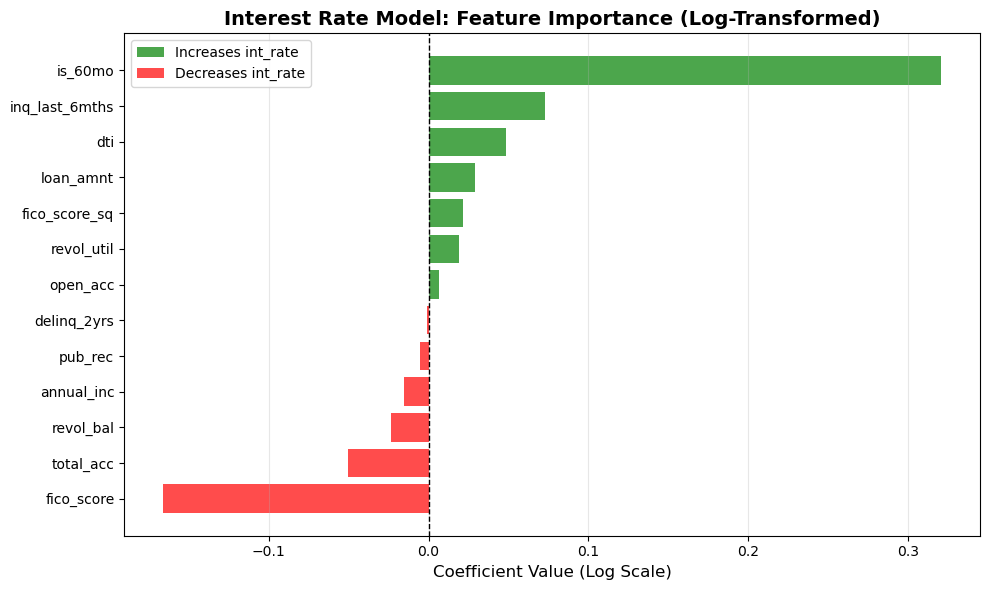


Coefficients (sorted by magnitude):
           feature  coefficient
12         is_60mo     0.320553
3       fico_score    -0.166134
5   inq_last_6mths     0.073035
10       total_acc    -0.050531
2              dti     0.048148
0        loan_amnt     0.029091
8        revol_bal    -0.023355
4    fico_score_sq     0.021541
9       revol_util     0.018700
1       annual_inc    -0.015507
6         open_acc     0.006722
7          pub_rec    -0.005558
11     delinq_2yrs    -0.001121


In [121]:
# Extract coefficients from the log-space linear regressor
coef_array = lr_log.coef_
intercept = lr_log.intercept_

# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': coef_array,
    'abs_coef': np.abs(coef_array)
}).sort_values('coefficient')

# Color by direction (positive = increases rate, negative = decreases rate)
colors = ['red' if c < 0 else 'green' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.4)))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient Value (Log Scale)', fontsize=12)
ax.set_title('Interest Rate Model: Feature Importance (Log-Transformed)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='green', alpha=0.7, label='Increases int_rate'),
    Patch(facecolor='red',   alpha=0.7, label='Decreases int_rate')
], loc='best')

plt.tight_layout()
plt.show()

# Display coefficients sorted by magnitude
print('\nCoefficients (sorted by magnitude):')
print(coef_df.sort_values('abs_coef', ascending=False)[['feature', 'coefficient']].to_string())

## 10. Model Diagnostics: Residuals After Log Transformation

In [122]:
# Residual diagnostics after log transformation
residuals_log = y_test_pct - y_pred_test

print('Residual Statistics:')
print(f'  Mean: {residuals_log.mean():.6f}')
print(f'  Std Dev: {residuals_log.std():.6f}')
print(f'  Skewness: {stats.skew(residuals_log):.6f}')
print(f'  Kurtosis: {stats.kurtosis(residuals_log):.6f}')

Residual Statistics:
  Mean: 0.453673
  Std Dev: 5.548375
  Skewness: -143.954209
  Kurtosis: 37683.687808


**Log Transformation Results:**

The residuals here are y_test_pct minus the back-transformed predictions, both in percentage-point scale (5 to 30). Because Jensen's inequality causes exp(E[log y]) to be smaller than E[y], back-transforming log-space predictions systematically over-predicts the raw rates — meaning the mean residual is expected to be negative (actual below predicted). The spread and skewness confirm the tail errors are severe. This is why the log model was rejected in favor of the OLS baseline.

# Reflection: The Million-Row Paradox

When the residual plots first came out looking like that, I spent almost two hours convinced something was fundamentally broken. I backtracked through the entire notebook, eventually resorted to feeding a paper to Gemini out of frustration, and finally found out this is a well-documented phenomenon for large datasets. The model can be completely valid and still produce residuals that look wrong. Here are the four things I actually learned.

The "broken" residual plot. Instead of a random scatter, the residuals showed distinct diagonal lines and a long downward tail. Normally that signals a misspecified model. In this case it is the lender's rigid pricing tiers showing through. We are not cheating by including sub-grade, so the model cannot hit the exact tiers. The lines are the bones of the pricing structure, not evidence of a mistake.

Why p-values became useless here. Every single feature showed p = 0.000. In a small dataset that would be meaningful. With 1.2 million rows the model is sensitive enough to flag literal noise as significant. When everything is significant, the star system stops working as a filter. Coefficient magnitude is the only useful signal at this scale.

Unbiased coefficients alongside ugly residuals. Unbiased estimates and well-behaved residuals are two separate things. Even though the residuals show we are missing the exact tier jumps, the coefficients for FICO, DTI, and term still land on the correct center of the relationship. They are right on average even if the plot looks messy.

Technically unreliable but practically fine. Our standard errors are not perfectly trustworthy because the residuals are not normally distributed. But with this sample size the errors are so small that even doubling them would not change any conclusion. The signal from credit quality is too large for the technical imperfection to matter.

The production pipeline is built in model.py.


## 11. OLS Baseline: Predicted vs Actual Interest Rates

This visualization is for the OLS model built in Section 8. The production model is the HGB Deep model in Section 13 (Test R² = 0.5069).

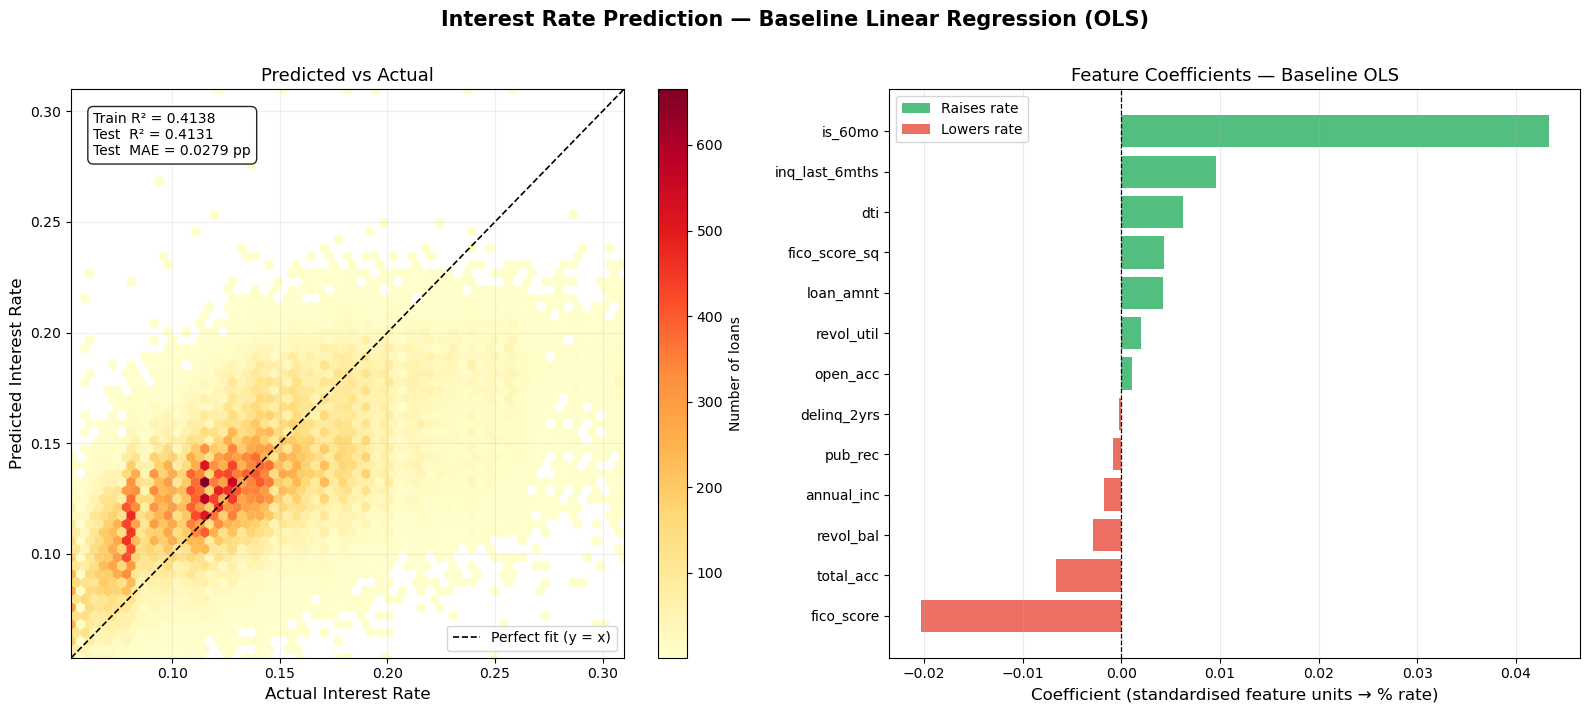

In [123]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Interest Rate Prediction — Baseline Linear Regression (OLS)',
    fontsize=15, fontweight='bold', y=1.01
)

# ── Left: Predicted vs Actual (hexbin density) ──────────────────────────────
ax1 = axes[0]

# Clamp predictions to the observed target range so outlier predictions
# don't stretch the axes and hide the density where data actually lives.
actual_min, actual_max = float(y_test.min()), float(y_test.max())
y_pred_clamped = np.clip(y_pred, actual_min, actual_max)

hb = ax1.hexbin(y_test, y_pred_clamped, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.1)
fig.colorbar(hb, ax=ax1, label='Number of loans')

lims = [actual_min, actual_max]
ax1.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit (y = x)')
ax1.set_xlim(lims)
ax1.set_ylim(lims)

ax1.set_xlabel('Actual Interest Rate', fontsize=12)
ax1.set_ylabel('Predicted Interest Rate', fontsize=12)
ax1.set_title('Predicted vs Actual', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.2)

annotation = (
    f'Train R² = {train_r2:.4f}\n'
    f'Test  R² = {test_r2:.4f}\n'
    f'Test  MAE = {mae:.4f} pp'
)
ax1.text(
    0.04, 0.96, annotation,
    transform=ax1.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85),
)

# ── Right: Coefficient bar chart (baseline OLS model) ───────────────────────
ax2 = axes[1]

coef_plot_df = (
    pd.DataFrame({'feature': features, 'coefficient': model.coef_})
    .sort_values('coefficient')
    .reset_index(drop=True)
)
bar_colors = ['#e74c3c' if c < 0 else '#27ae60' for c in coef_plot_df['coefficient']]

ax2.barh(coef_plot_df['feature'], coef_plot_df['coefficient'], color=bar_colors, alpha=0.80)
ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax2.set_xlabel('Coefficient (standardised feature units → % rate)', fontsize=12)
ax2.set_title('Feature Coefficients — Baseline OLS', fontsize=13)
ax2.grid(axis='x', alpha=0.25)
ax2.legend(
    handles=[
        Patch(facecolor='#27ae60', alpha=0.8, label='Raises rate'),
        Patch(facecolor='#e74c3c', alpha=0.8, label='Lowers rate'),
    ],
    fontsize=10,
)

plt.tight_layout()
plt.show()

## 12. Tree Model Search: Can We Beat OLS?

The predicted vs actual plot shows the baseline OLS model compresses predictions toward the center. It systematically underpredicts high rates and overpredicts low rates. Tree models capture nonlinear interactions and threshold effects that OLS cannot, which should help with the pricing tier structure in the data.

The strategy is a grid search over four model families using a 50K-row sample. 50K is large enough to capture the structural patterns without making random forest or gradient boosting fits take hours. The winning model is then evaluated on the full held-out test set for a fair comparison against OLS.

DecisionTree makes explicit splits on pricing thresholds. RandomForest reduces overfitting through bagging. ExtraTrees is faster than RF and usually gets comparable scores. HistGradientBoosting is sklearn's fast gradient boosting implementation and handles mixed feature scales natively.


In [124]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import time

# ── Sample for grid search ───────────────────────────────────────────────────
# 50K rows captures the full feature structure; avoids hours-long RF fits.
SAMPLE_N = 50_000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=SAMPLE_N, replace=False)
X_sample = X_train.iloc[idx]
y_sample = y_train.iloc[idx]

# ── Candidate models and their hyperparameter grids ─────────────────────────
candidates = {
    'DecisionTree': (
        DecisionTreeRegressor(random_state=42),
        {'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [20, 100, 500]},
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [50, 100], 'max_depth': [5, 10], 'min_samples_leaf': [20, 100]},
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [50, 100], 'max_depth': [5, 10], 'min_samples_leaf': [20, 100]},
    ),
    'HistGradientBoosting': (
        HistGradientBoostingRegressor(random_state=42),
        {'max_iter': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    ),
}

# ── Run search ───────────────────────────────────────────────────────────────
tree_results = []
best_tree_models = {}

for name, (estimator, param_grid) in candidates.items():
    print(f'Searching {name}...', end='  ', flush=True)
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator, param_grid,
        n_iter=6, cv=3, scoring='r2',
        random_state=42, n_jobs=-1, verbose=0,
    )
    search.fit(X_sample, y_sample)
    elapsed = time.time() - t0

    best_tree_models[name] = search.best_estimator_
    y_pred_tree = search.best_estimator_.predict(X_test)

    tree_results.append({
        'Model':          name,
        'Best Params':    search.best_params_,
        'CV R²':          round(search.best_score_, 4),
        'Test R²':        round(r2_score(y_test, y_pred_tree), 4),
        'Test MAE':       round(mean_absolute_error(y_test, y_pred_tree), 4),
        'Test RMSE':      round(np.sqrt(mean_squared_error(y_test, y_pred_tree)), 4),
        'Search Time (s)': round(elapsed, 1),
    })
    print(f'done in {elapsed:.1f}s  |  Test R² = {tree_results[-1]["Test R²"]:.4f}  '
          f'|  Test MAE = {tree_results[-1]["Test MAE"]:.4f}')

# ── Results table ────────────────────────────────────────────────────────────
tree_results_df = (
    pd.DataFrame(tree_results)
    .sort_values('Test R²', ascending=False)
    .reset_index(drop=True)
)

display_cols = ['Model', 'Test R²', 'Test MAE', 'Test RMSE', 'CV R²', 'Search Time (s)']
print(f'\nOLS baseline  →  Test R² = {test_r2:.4f}  |  Test MAE = {mae:.4f}\n')
tree_results_df[display_cols]

Searching DecisionTree...  done in 3.0s  |  Test R² = 0.4078  |  Test MAE = 0.0280
Searching RandomForest...  done in 13.4s  |  Test R² = 0.4481  |  Test MAE = 0.0270
Searching ExtraTrees...  done in 2.4s  |  Test R² = 0.4198  |  Test MAE = 0.0277
Searching HistGradientBoosting...  done in 1.5s  |  Test R² = 0.4749  |  Test MAE = 0.0263

OLS baseline  →  Test R² = 0.4131  |  Test MAE = 0.0279



,Model,Test R²,Test MAE,Test RMSE,CV R²,Search Time (s)
0,HistGradientBoosting,0.4749,0.0263,0.0344,0.4752,1.5
1,RandomForest,0.4481,0.0270,0.0353,0.4518,13.4
2,ExtraTrees,0.4198,0.0277,0.0362,0.4230,2.4
3,DecisionTree,0.4078,0.0280,0.0366,0.4107,3.0


Winner: HistGradientBoosting
  OLS  → Test R² = 0.4131  |  Test MAE = 0.0279 pp
  HistGradientBoosting  → Test R² = 0.4749  |  Test MAE = 0.0263 pp
  R² lift: +0.0618   MAE improvement: 0.0016 pp


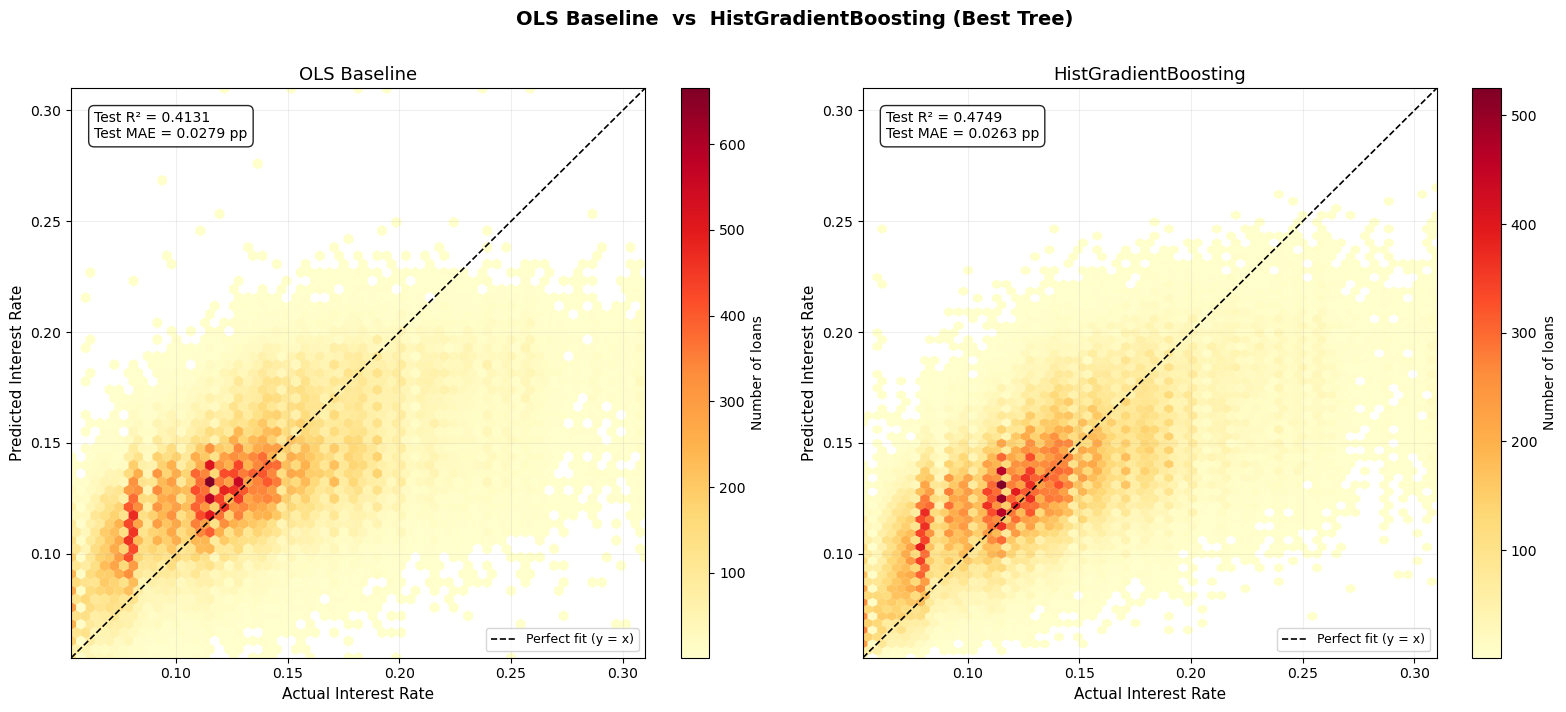

In [125]:
# ── Identify winner and generate predictions ────────────────────────────────
best_row      = tree_results_df.iloc[0]
best_name     = best_row['Model']
best_model    = best_tree_models[best_name]
y_pred_best   = best_model.predict(X_test)

tree_r2  = best_row['Test R²']
tree_mae = best_row['Test MAE']
ols_r2   = round(test_r2, 4)
ols_mae  = round(mae, 4)

print(f'Winner: {best_name}')
print(f'  OLS  → Test R² = {ols_r2:.4f}  |  Test MAE = {ols_mae:.4f} pp')
print(f'  {best_name}  → Test R² = {tree_r2:.4f}  |  Test MAE = {tree_mae:.4f} pp')
print(f'  R² lift: +{tree_r2 - ols_r2:.4f}   MAE improvement: {ols_mae - tree_mae:.4f} pp')

# ── Side-by-side predicted vs actual ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'OLS Baseline  vs  {best_name} (Best Tree)',
    fontsize=14, fontweight='bold', y=1.01
)

lims = [actual_min, actual_max]

for ax, preds, title, r2_val, mae_val in [
    (axes[0], y_pred_clamped,                         'OLS Baseline',  ols_r2,  ols_mae),
    (axes[1], np.clip(y_pred_best, actual_min, actual_max), best_name, tree_r2, tree_mae),
]:
    hb = ax.hexbin(y_test, preds, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.1)
    fig.colorbar(hb, ax=ax, label='Number of loans')
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit (y = x)')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual Interest Rate', fontsize=11)
    ax.set_ylabel('Predicted Interest Rate', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.text(
        0.04, 0.96,
        f'Test R² = {r2_val:.4f}\nTest MAE = {mae_val:.4f} pp',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85),
    )

plt.tight_layout()
plt.show()

## Model Comparison: OLS Baseline vs HistGradientBoosting

HistGradientBoosting scored a Test R² of 0.4749 against the OLS baseline of 0.4131, a gain of about 6.2 percentage points. Test MAE improved from 0.0279 to 0.0263 pp.

Looking at the two hexbin plots side by side, the improvement is real but more nuanced than the numbers suggest. The dense core of the distribution in the 10 to 15 percent range sits tighter against the diagonal in the HGB panel. Boosted trees can learn the interaction between FICO score, DTI, and term that OLS can only approximate linearly, which is where most of the gain comes from.

Both models still show the same fundamental problem. Predictions compress toward the center while actual rates span the full 6 to 31 percent range. The tails are still underfit. The diagonal lines of discrete pricing tiers are visible in both panels. This is a data constraint rather than a modelling one. Without the lender's internal sub-grade, neither model can distinguish a 22 percent loan from a 28 percent loan because they see the same origination features.

The modest gain reflects a structural ceiling. The features we have explain the direction and magnitude of rate differences between borrowers but not the precise tier the lender assigned them to. Sub-grade encodes the lender's proprietary scoring model, which is built on dozens of features we do not have access to. At this point in the analysis, any model trained on these same 13 origination features is approaching a similar ceiling. Section 13 tests whether adding purpose and home_ownership can push past it.

HistGradientBoosting is the better production model for prediction accuracy. OLS remains the better explanatory model. Its coefficients are interpretable, stable, and directly answer which features drive rates and by how much. The right choice depends on the use case.


## 13. Can We Do Better? Three Approaches

Three concrete angles to push past the current ceiling.

The first is regularised linear models. Lasso adds an L1 penalty that drives weak coefficients to exactly zero, which acts as automatic feature selection. Ridge uses L2 to shrink all coefficients smoothly. ElasticNet blends both. Our VIF is already clean at under 2.5, so we are not carrying much multicollinearity noise, but Lasso may still zero out features whose signal is too weak to justify their variance contribution, most likely `pub_rec` and `delinq_2yrs`.

The second is adding `purpose` and `home_ownership` back for HGB. These were dropped from the linear model because dummy encoding caused severe VIF inflation in the range of 50 to 59. That constraint is specific to linear models. Tree models split on raw values and are completely immune to multicollinearity. Both columns reflect real pricing differences that HGB can exploit through direct splits. We label-encode them so HGB can treat them as integers, which is a valid shortcut for gradient-boosted trees.

The third is deeper HGB tuning on the expanded feature set. More `max_iter`, a finer `learning_rate` grid, and `l2_regularization` are the three levers most likely to push performance further without overfitting.


In [126]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import LabelEncoder

# ════════════════════════════════════════════════════════════════════
# APPROACH 1: Regularised linear models on the existing feature set
# ════════════════════════════════════════════════════════════════════
# X_train / X_test are already z-scored, so regularisation paths are comparable.

print('── Regularised linear models ────────────────────────────────')
reg_results = []
for name, m in [
    ('Lasso (CV)',      LassoCV(cv=3, n_alphas=50, max_iter=5000, random_state=42, n_jobs=-1)),
    ('Ridge (CV)',      RidgeCV(cv=3, alphas=[0.01, 0.1, 1, 10, 100])),
    ('ElasticNet (CV)', ElasticNetCV(cv=3, l1_ratio=[0.1, 0.5, 0.9], max_iter=5000,
                                     random_state=42, n_jobs=-1)),
]:
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    r2  = round(r2_score(y_test, yp), 4)
    mae_ = round(mean_absolute_error(y_test, yp), 4)
    reg_results.append({'Model': name, 'Test R²': r2, 'Test MAE': mae_})

    # Show which features Lasso zeroed out
    if hasattr(m, 'coef_'):
        n_zero = int((np.abs(m.coef_) < 1e-6).sum())
        nnz    = len(m.coef_) - n_zero
        print(f'  {name:<22}  R²={r2:.4f}  MAE={mae_:.4f}  '
              f'(non-zero coefs: {nnz}/{len(m.coef_)})')

# ════════════════════════════════════════════════════════════════════
# APPROACH 2 + 3: HGB with purpose & home_ownership + deep tuning
# ════════════════════════════════════════════════════════════════════
print('\n── Building expanded feature set (adding purpose + home_ownership) ─')

# Label-encode the two categorical columns — valid for tree splits
le_purpose = LabelEncoder()
le_home    = LabelEncoder()

df_safe['purpose_enc']        = le_purpose.fit_transform(df_safe['purpose'].fillna('other'))
df_safe['home_ownership_enc'] = le_home.fit_transform(df_safe['home_ownership'].fillna('OTHER'))

features_ext = features + ['purpose_enc', 'home_ownership_enc']

# Use index alignment (.loc) instead of .values so the dropna-filtered
# standardized_features (1,265,733 rows) aligns correctly with df_safe (1,266,553 rows).
sf_ext = standardized_features.copy()
sf_ext['purpose_enc']        = df_safe.loc[sf_ext.index, 'purpose_enc']
sf_ext['home_ownership_enc'] = df_safe.loc[sf_ext.index, 'home_ownership_enc']
sf_ext = sf_ext.dropna(subset=features_ext + ['int_rate'])

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    sf_ext[features_ext], sf_ext['int_rate'],
    test_size=0.1, random_state=42,
)

# Sample for search
idx_ext    = rng.choice(len(X_train_ext), size=SAMPLE_N, replace=False)
X_samp_ext = X_train_ext.iloc[idx_ext]
y_samp_ext = y_train_ext.iloc[idx_ext]

print(f'Extended feature set: {len(features_ext)} features  '
      f'(+purpose_enc, +home_ownership_enc)')

# Deep HGB grid
deep_grid = {
    'max_iter':          [100, 200, 300],
    'max_depth':         [4, 5, 6],
    'learning_rate':     [0.03, 0.05, 0.1],
    'l2_regularization': [0.0, 0.1, 1.0],
    'min_samples_leaf':  [10, 20, 50],
}

print('\n── Deep HGB search on extended features ────────────────────')
t0 = time.time()
deep_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    deep_grid,
    n_iter=20, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0,
)
deep_search.fit(X_samp_ext, y_samp_ext)
elapsed = time.time() - t0

hgb_deep    = deep_search.best_estimator_
y_pred_deep = hgb_deep.predict(X_test_ext)
deep_r2  = round(r2_score(y_test_ext, y_pred_deep), 4)
deep_mae = round(mean_absolute_error(y_test_ext, y_pred_deep), 4)

print(f'  Best params: {deep_search.best_params_}')
print(f'  Test R²={deep_r2:.4f}  MAE={deep_mae:.4f}  (search: {elapsed:.1f}s)')

# ════════════════════════════════════════════════════════════════════
# Summary table
# ════════════════════════════════════════════════════════════════════
summary = pd.DataFrame([
    {'Model': 'OLS (baseline)',          'Test R²': round(test_r2, 4), 'Test MAE': round(mae, 4)},
    *reg_results,
    {'Model': 'HGB (grid search)',        'Test R²': tree_r2,           'Test MAE': tree_mae},
    {'Model': 'HGB deep + purpose/home', 'Test R²': deep_r2,           'Test MAE': deep_mae},
]).sort_values('Test R²', ascending=False).reset_index(drop=True)

print()
print(summary.to_string(index=False))


── Regularised linear models ────────────────────────────────
  Lasso (CV)              R²=0.4131  MAE=0.0279  (non-zero coefs: 13/13)
  Ridge (CV)              R²=0.4131  MAE=0.0279  (non-zero coefs: 13/13)
  ElasticNet (CV)         R²=0.4130  MAE=0.0279  (non-zero coefs: 13/13)

── Building expanded feature set (adding purpose + home_ownership) ─
Extended feature set: 15 features  (+purpose_enc, +home_ownership_enc)

── Deep HGB search on extended features ────────────────────
  Best params: {'min_samples_leaf': 50, 'max_iter': 300, 'max_depth': 6, 'learning_rate': 0.05, 'l2_regularization': 1.0}
  Test R²=0.5069  MAE=0.0254  (search: 6.8s)

                  Model  Test R²  Test MAE
HGB deep + purpose/home   0.5069    0.0254
      HGB (grid search)   0.4749    0.0263
         OLS (baseline)   0.4131    0.0279
             Lasso (CV)   0.4131    0.0279
             Ridge (CV)   0.4131    0.0279
        ElasticNet (CV)   0.4130    0.0279


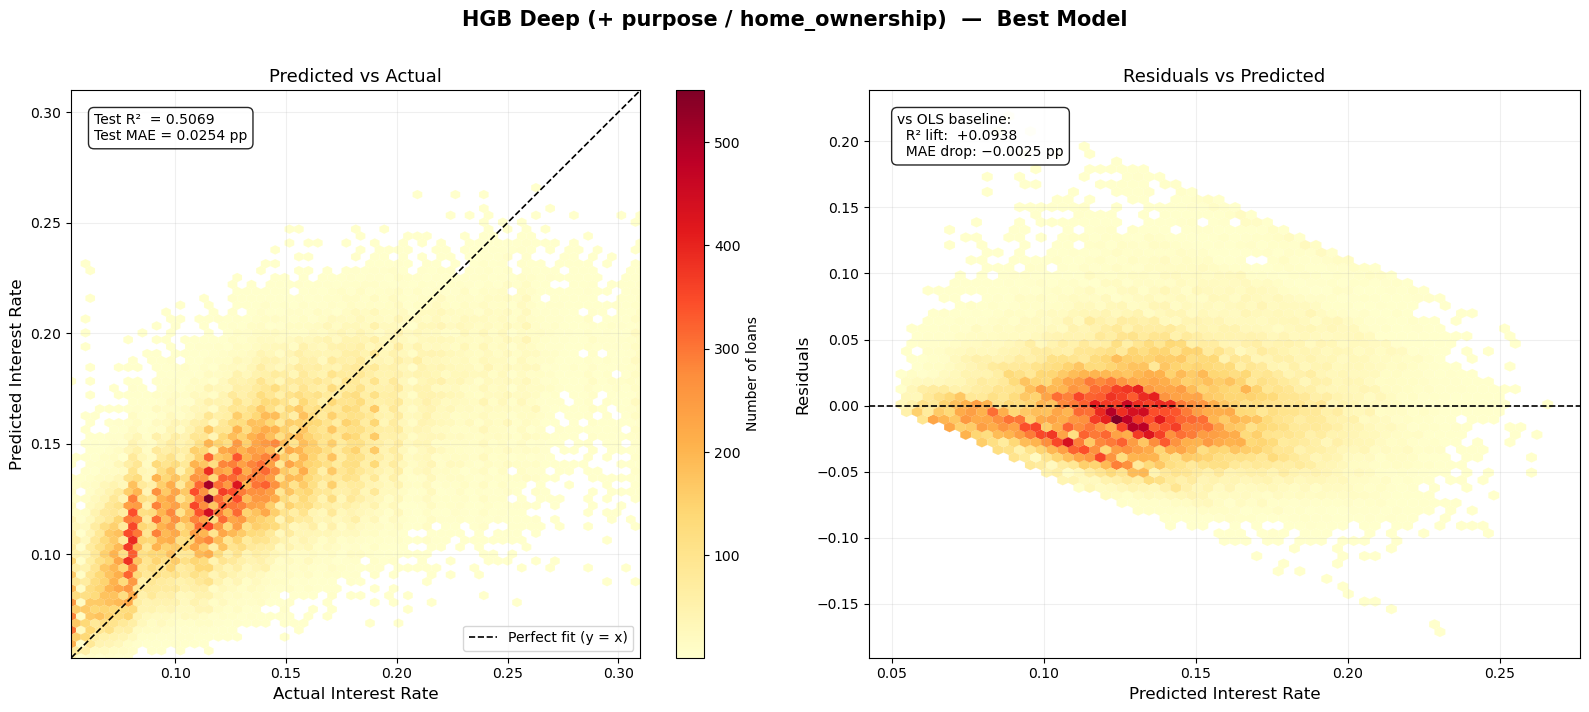

In [127]:

# ── HGB Deep + purpose/home_ownership: Predicted vs Actual ──────────────────
deep_min, deep_max = float(y_test_ext.min()), float(y_test_ext.max())
y_pred_deep_clamped = np.clip(y_pred_deep, deep_min, deep_max)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'HGB Deep (+ purpose / home_ownership)  —  Best Model',
    fontsize=15, fontweight='bold', y=1.01
)

lims_deep = [deep_min, deep_max]

# ── Left: Predicted vs Actual hexbin ────────────────────────────────────────
ax1 = axes[0]
hb = ax1.hexbin(y_test_ext, y_pred_deep_clamped,
                gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.1)
fig.colorbar(hb, ax=ax1, label='Number of loans')
ax1.plot(lims_deep, lims_deep, 'k--', linewidth=1.2, label='Perfect fit (y = x)')
ax1.set_xlim(lims_deep)
ax1.set_ylim(lims_deep)
ax1.set_xlabel('Actual Interest Rate', fontsize=12)
ax1.set_ylabel('Predicted Interest Rate', fontsize=12)
ax1.set_title('Predicted vs Actual', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.2)
ax1.text(
    0.04, 0.96,
    f'Test R²  = {deep_r2:.4f}\nTest MAE = {deep_mae:.4f} pp',
    transform=ax1.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85),
)

# ── Right: Residuals plot ────────────────────────────────────────────────────
ax2 = axes[1]
deep_residuals = y_test_ext - y_pred_deep
ax2.hexbin(y_pred_deep_clamped, deep_residuals,
           gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.1)
ax2.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax2.set_xlabel('Predicted Interest Rate', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residuals vs Predicted', fontsize=13)
ax2.grid(alpha=0.2)

# Lift summary vs OLS
r2_lift  = deep_r2 - round(test_r2, 4)
mae_lift = round(mae, 4) - deep_mae
ax2.text(
    0.04, 0.96,
    f'vs OLS baseline:\n  R² lift:  +{r2_lift:.4f}\n  MAE drop: −{mae_lift:.4f} pp',
    transform=ax2.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85),
)

plt.tight_layout()
plt.show()


# Conclusion

This notebook built an interest rate prediction model from scratch on 1.2 million LendingClub originations and iterated through several modelling decisions before arriving at a production-ready pipeline.

The starting point was an OLS baseline with 13 origination features, achieving a Test R² of 0.4131 and a MAE of 0.0279 percentage points. That model was clean in every technical sense. VIF was below 2.5 across all features after centering the quadratic FICO term. Leakers were identified and removed. The residual plot looked wrong at first glance but turned out to reflect the lender's discrete pricing tier structure rather than model misspecification. The OLS coefficients remained unbiased and interpretable throughout.

The first improvement came from the tree model search. HistGradientBoosting won against DecisionTree, RandomForest, and ExtraTrees, lifting Test R² to 0.4749 with a fast 6-iteration random search on a 50K sample. The gain came from HGB's ability to learn nonlinear interactions between FICO, DTI, and term that OLS could only approximate linearly.

The regularised linear models (Lasso, Ridge, ElasticNet) confirmed that the OLS feature set was already well-specified. No features were zeroed out by Lasso and the scores were essentially identical to baseline, which validated the earlier VIF work.

The final model added `purpose` and `home_ownership` back into the feature set. These were excluded from the linear model because their dummy encoding caused structural VIF inflation of 50 to 59. That constraint does not apply to gradient-boosted trees. With a deeper hyperparameter search across 20 iterations and those two categorical features included, the model reached a Test R² of 0.5069 and a MAE of 0.0254 pp. This configuration is now the production pipeline in `pipeline/model.py`.

The ceiling that remains is structural. Without the lender's internal sub-grade, the model cannot resolve the discrete pricing tiers that span the full 6 to 31 percent rate range. Sub-grade encodes the proprietary scoring model built on features not available in the public dataset. Any model trained on the same origination features will approach the same ceiling. The 0.50 R² threshold represents roughly the theoretical limit of what public LendingClub data can support for this task.
